# Onde se localiza as zonas com maior consumo doméstico e não doméstico ?

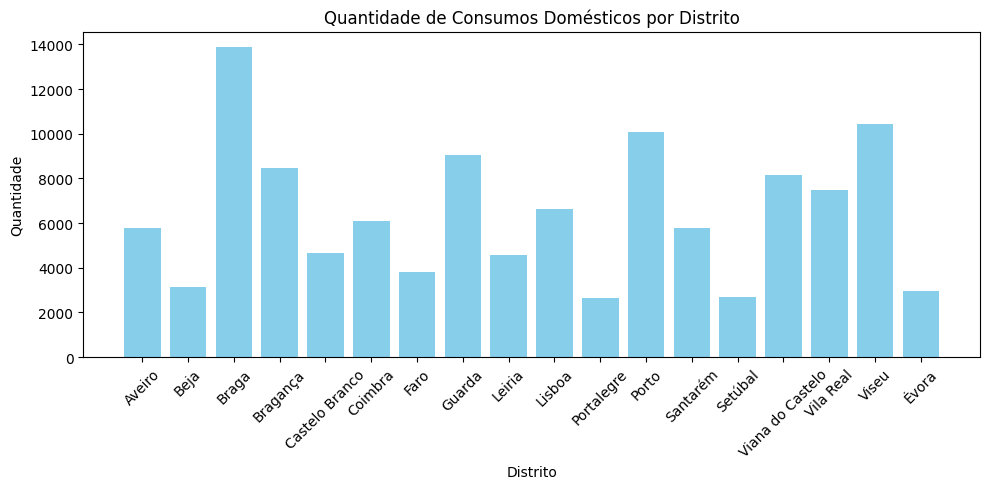

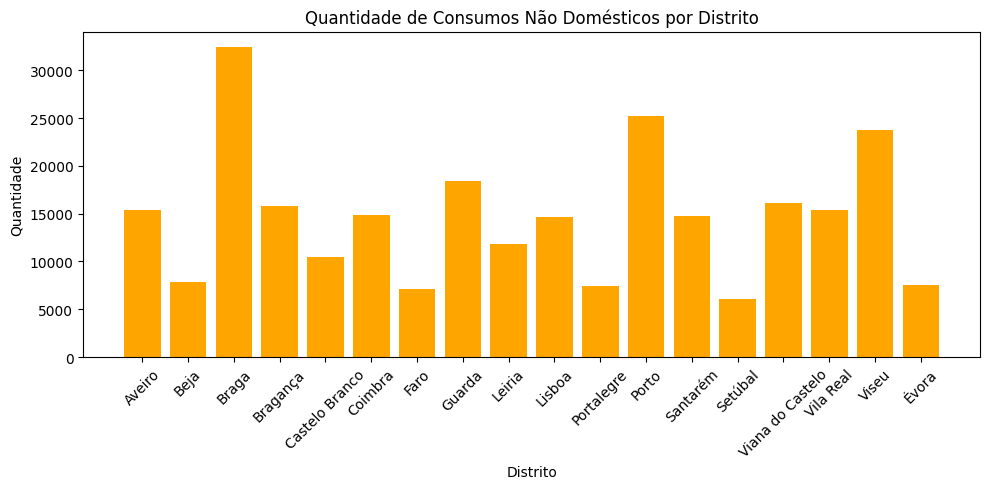

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

# Carregar o dataset
df = pd.read_csv('./data/caracterizacao-contrato-ativo.csv', sep=';')

# Filtrar apenas doméstico e não doméstico
df_filtrado = df[df['tipo_de_instalacao'].isin(['Doméstico', 'Não Doméstico'])]

# Agrupar por Distrito e tipo de instalação, contando as ocorrências (ou poderia ser soma de consumo se houver)
df_grouped = df_filtrado.groupby(['Distrito', 'tipo_de_instalacao']).size().reset_index(name='quantidade')

# Separar os dados
df_domestico = df_grouped[df_grouped['tipo_de_instalacao'] == 'Doméstico']
df_nao_domestico = df_grouped[df_grouped['tipo_de_instalacao'] == 'Não Doméstico']

# Plot Doméstico
plt.figure(figsize=(10, 5))
plt.bar(df_domestico['Distrito'], df_domestico['quantidade'], color='skyblue')
plt.xticks(rotation=45)
plt.title('Quantidade de Consumos Domésticos por Distrito')
plt.xlabel('Distrito')
plt.ylabel('Quantidade')
plt.tight_layout()
plt.show()

# Plot Não Doméstico
plt.figure(figsize=(10, 5))
plt.bar(df_nao_domestico['Distrito'], df_nao_domestico['quantidade'], color='orange')
plt.xticks(rotation=45)
plt.title('Quantidade de Consumos Não Domésticos por Distrito')
plt.xlabel('Distrito')
plt.ylabel('Quantidade')
plt.tight_layout()
plt.show()


In [2]:
# Somar Doméstico + Não Doméstico por Distrito
df_total = df_grouped.groupby('Distrito')['quantidade'].sum().reset_index()
df_total = df_total.rename(columns={'quantidade': 'Numero_instalacoes'})


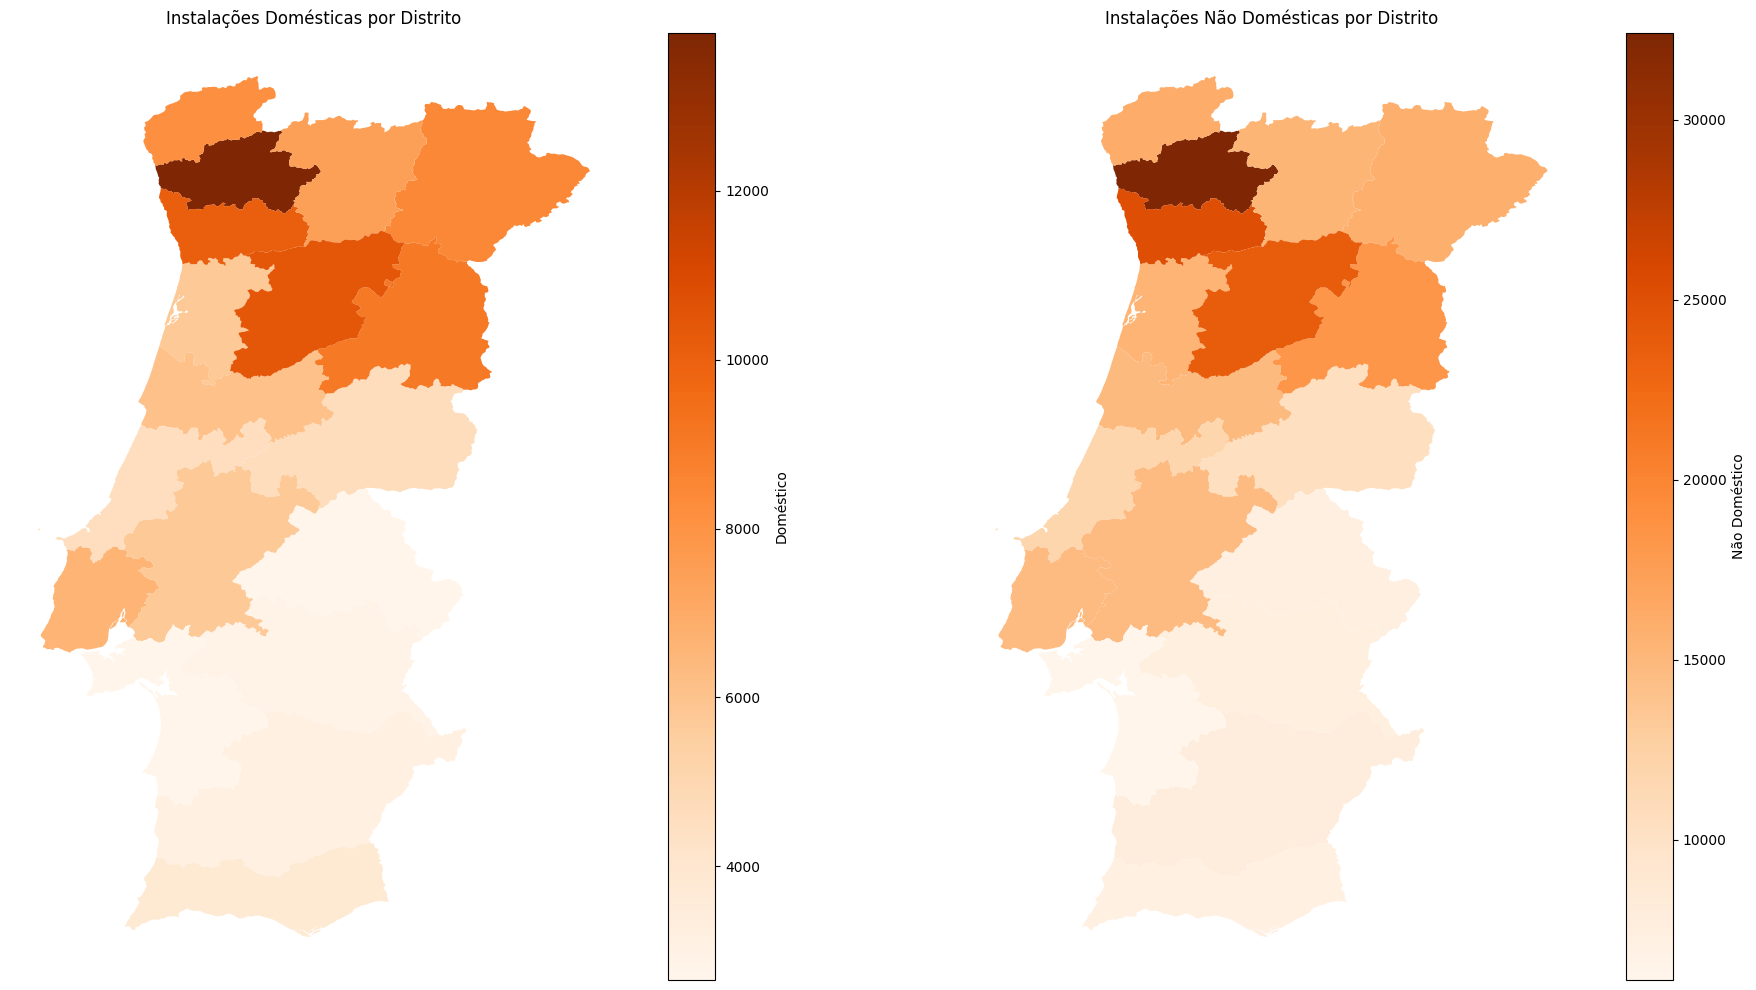

In [4]:
# --- Separação dos dados ---
df_domestico = df_grouped[df_grouped['tipo_de_instalacao'] == 'Doméstico']
df_nao_domestico = df_grouped[df_grouped['tipo_de_instalacao'] == 'Não Doméstico']

# Carregar o shapefile de Portugal (ajustar o caminho conforme necessário)
mapa_pt = gpd.read_file('./pt.json')

# Se o nome da coluna no shapefile não for 'Distrito', renomeie para 'Distrito'
if 'NAME_1' in mapa_pt.columns:
    mapa_pt = mapa_pt.rename(columns={'NAME_1': 'Distrito'})
    
# --- Merge com shapefile ---
mapa_domestico = mapa_pt.merge(df_domestico, on='Distrito', how='left')
mapa_nao_domestico = mapa_pt.merge(df_nao_domestico, on='Distrito', how='left')

# --- Plot lado a lado ---
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Mapa Doméstico
mapa_domestico.plot(column='quantidade', 
                    cmap='Oranges', 
                    legend=True, 
                    ax=axes[0],
                    legend_kwds={'label': "Doméstico", 'orientation': "vertical"})
axes[0].set_title("Instalações Domésticas por Distrito")
axes[0].axis('off')

# Mapa Não Doméstico
mapa_nao_domestico.plot(column='quantidade', 
                        cmap='Oranges', 
                        legend=True, 
                        ax=axes[1],
                        legend_kwds={'label': "Não Doméstico", 'orientation': "vertical"})
axes[1].set_title("Instalações Não Domésticas por Distrito")
axes[1].axis('off')

plt.tight_layout()
plt.show()
